In [1]:
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine(
    "",
    connect_args={"sslmode": "require"}
)

In [2]:
df = pd.read_sql(
    'SELECT * FROM "Water_abstracted_by_business_entitiess";',
    engine
)
df

,Id,Year,WaterSourceType,Total,MiningAndQuarrying,ManufacturingIndustry,ElectricityGasSupply,AgricultureForestryFishing,WaterSupplyWasteManagement,Construction
0,16,2015,Total,4316.0,10.0,25.0,4281.0,0.0,0.0,0.0
1,17,2015,Ground water,4.0,NaN,4.0,NaN,NaN,NaN,NaN
2,18,2015,Springs,2178.0,NaN,11.0,2167.0,NaN,NaN,NaN
3,19,2015,Surface water,2100.0,9.0,4.0,2087.0,NaN,NaN,NaN
4,20,2015,Public water supply,32.0,NaN,5.0,27.0,NaN,NaN,NaN
5,21,2015,Other,1.0,NaN,1.0,NaN,NaN,NaN,NaN
6,22,2016,Total,3721.0,14.0,27.0,3679.0,NaN,NaN,NaN
7,23,2016,Ground water,22.0,0.0,21.0,NaN,NaN,NaN,NaN
8,24,2016,Springs,2665.0,NaN,2.0,2663.0,NaN,NaN,NaN
9,25,2016,Surface water,1022.0,14.0,1.0,1007.0,NaN,NaN,NaN


In [3]:
df = df.drop(columns=["Id"])

df = df.drop(columns=[
    "AgricultureForestryFishing",
    "WaterSupplyWasteManagement",
    "MiningAndQuarrying"
])

In [4]:
df = (
    df.sort_values(["WaterSourceType", "Year"])
      .groupby("WaterSourceType", group_keys=False)
      .apply(lambda x: x.bfill())
)

df

/var/folders/1r/8qsv6l4d2xs9tv69xpg5sfqw0000gn/T/ipykernel_16023/759868400.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.bfill())


,Year,WaterSourceType,Total,ManufacturingIndustry,ElectricityGasSupply,Construction
1,2015,Ground water,4.0,4.0,2.0,1.0
7,2016,Ground water,22.0,21.0,2.0,1.0
13,2017,Ground water,24.0,22.0,2.0,1.0
18,2018,Ground water,9.0,4.0,4.0,1.0
23,2019,Ground water,9.0,7.0,2.0,1.0
28,2020,Ground water,9.0,7.0,2.0,1.0
33,2021,Ground water,8.0,5.0,2.0,1.0
38,2022,Ground water,24.0,22.0,1.0,1.0
43,2023,Ground water,23.0,21.0,2.0,1.0
48,2024,Ground water,36.0,30.0,3.0,1.0


In [5]:
columns_to_model = df.columns.drop(["Year", "WaterSourceType"])

future_years = pd.DataFrame({"Year": [2025, 2026, 2027, 2028, 2029]})

In [6]:
from sklearn.linear_model import LinearRegression
import joblib
import os

model_dir = "../models/Water_abstracted_by_business_entitiess"
os.makedirs(model_dir, exist_ok=True)

In [7]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline


forecasts = []

for source in df["WaterSourceType"].unique():
    df_source = df[df["WaterSourceType"] == source]

    for col in columns_to_model:
        df_model = df_source[["Year", col]].dropna()

        if len(df_model) < 3:
            continue

        X = df_model[["Year"]].values
        y = df_model[col].values

        model = Pipeline([
            ("poly", PolynomialFeatures(degree=2, include_bias=False)),
            ("lr", LinearRegression())
        ])

        model.fit(X, y)

        preds = model.predict(future_years[["Year"]].values)

        for year, value in zip(future_years["Year"], preds):
            forecasts.append({
                "WaterSourceType": source,
                "Sector": col,
                "Year": year,
                "Forecast": value
            })

        joblib.dump(
            model,
            f"{model_dir}/{source}_{col}_poly2.pkl"
        )


In [8]:
forecast_df = pd.DataFrame(forecasts)
forecast_df

,WaterSourceType,Sector,Year,Forecast
0,Ground water,Total,2025,39.783333
1,Ground water,Total,2026,48.780303
2,Ground water,Total,2027,58.981818
3,Ground water,Total,2028,70.387879
4,Ground water,Total,2029,82.998485
...,...,...,...,...
95,Total,Construction,2025,0.700000
96,Total,Construction,2026,0.481818
97,Total,Construction,2027,0.218182
98,Total,Construction,2028,-0.090909


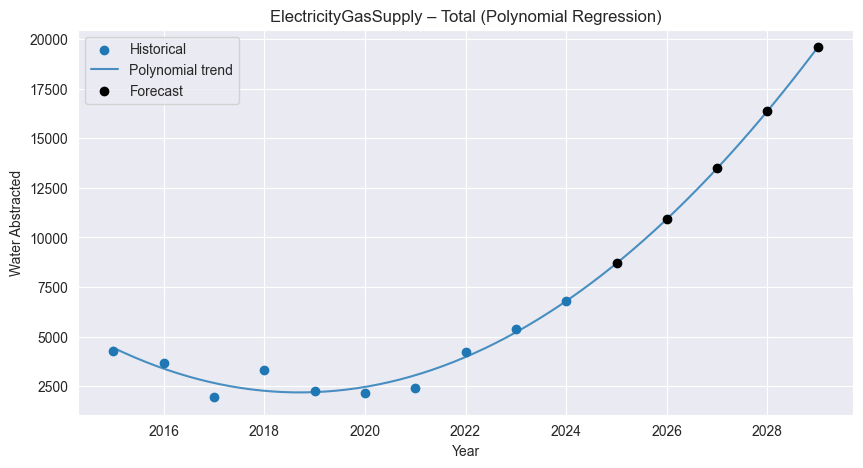

In [9]:
import matplotlib.pyplot as plt
import numpy as np

example_source = "Total"
example_sector = "ElectricityGasSupply"

hist = df[
    (df["WaterSourceType"] == example_source)
][["Year", example_sector]].dropna()

future = forecast_df[
    (forecast_df["WaterSourceType"] == example_source) &
    (forecast_df["Sector"] == example_sector)
    ]

years_smooth = np.linspace(hist["Year"].min(), future["Year"].max(), 200).reshape(-1, 1)

model = joblib.load(
    f"{model_dir}/{example_source}_{example_sector}_poly2.pkl"
)

y_smooth = model.predict(years_smooth)

plt.figure(figsize=(10, 5))
plt.scatter(hist["Year"], hist[example_sector], label="Historical", zorder=3)
plt.plot(years_smooth, y_smooth, label="Polynomial trend", alpha=0.8)
plt.scatter(future["Year"], future["Forecast"], color="black", label="Forecast", zorder=4)
plt.title(f"{example_sector} – {example_source} (Polynomial Regression)")
plt.xlabel("Year")
plt.ylabel("Water Abstracted")
plt.grid(True)
plt.legend()
plt.show()

In [3]:
df["WaterSourceType"].unique()

array(['Total', 'Ground water', 'Springs', 'Surface water',
       'Public water supply', 'Other'], dtype=object)